In [116]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
import matplotlib.ticker as mtick
wr.filterwarnings('ignore')

In [117]:
all_files = glob.glob("data/sold/raw/*.csv")

df = pd.concat((pd.read_csv(f, low_memory=False) for f in all_files), ignore_index=True)

cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeArea"]

restricted_df = df[
    (df['PropertyType'] == 'Residential') &
    (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(len(restricted_df))

358332


In [118]:
restricted_df.loc[:, cols].isnull().sum().rename('Null Values')

ClosePrice                  2
LivingArea                190
BedroomsTotal               0
BathroomsTotalInteger      50
LotSizeArea              6119
Name: Null Values, dtype: int64

In [119]:
restricted_df.duplicated().sum()

np.int64(31)

In [120]:
restricted_df.loc[:, cols].describe().T.style.format('{:,.0f}')

,count,mean,std,min,25%,50%,75%,max
ClosePrice,"358,330","1,300,739","5,506,689",0,"625,000","898,000","1,439,000","989,500,000"
LivingArea,"358,142","2,039","1,059",0,"1,380","1,808","2,428","123,764"
BedroomsTotal,"358,332",3,1,0,3,3,4,45
BathroomsTotalInteger,"358,282",3,1,0,2,2,3,175
LotSizeArea,"352,213","21,789","967,925",0,"5,458","7,100","9,938","418,742,280"


In [121]:
print('Zero prices:', (restricted_df['ClosePrice'] == 0).sum())

Zero prices: 1


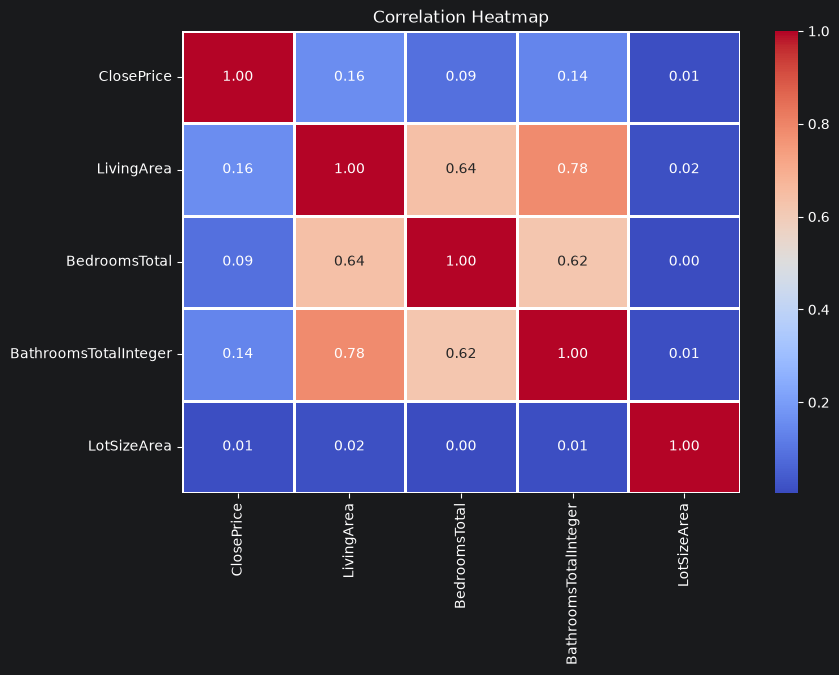

In [122]:
plt.figure(figsize=(9, 6))

sns.heatmap(restricted_df.loc[:, cols].corr(), cmap="coolwarm", annot=True, fmt='.2f', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

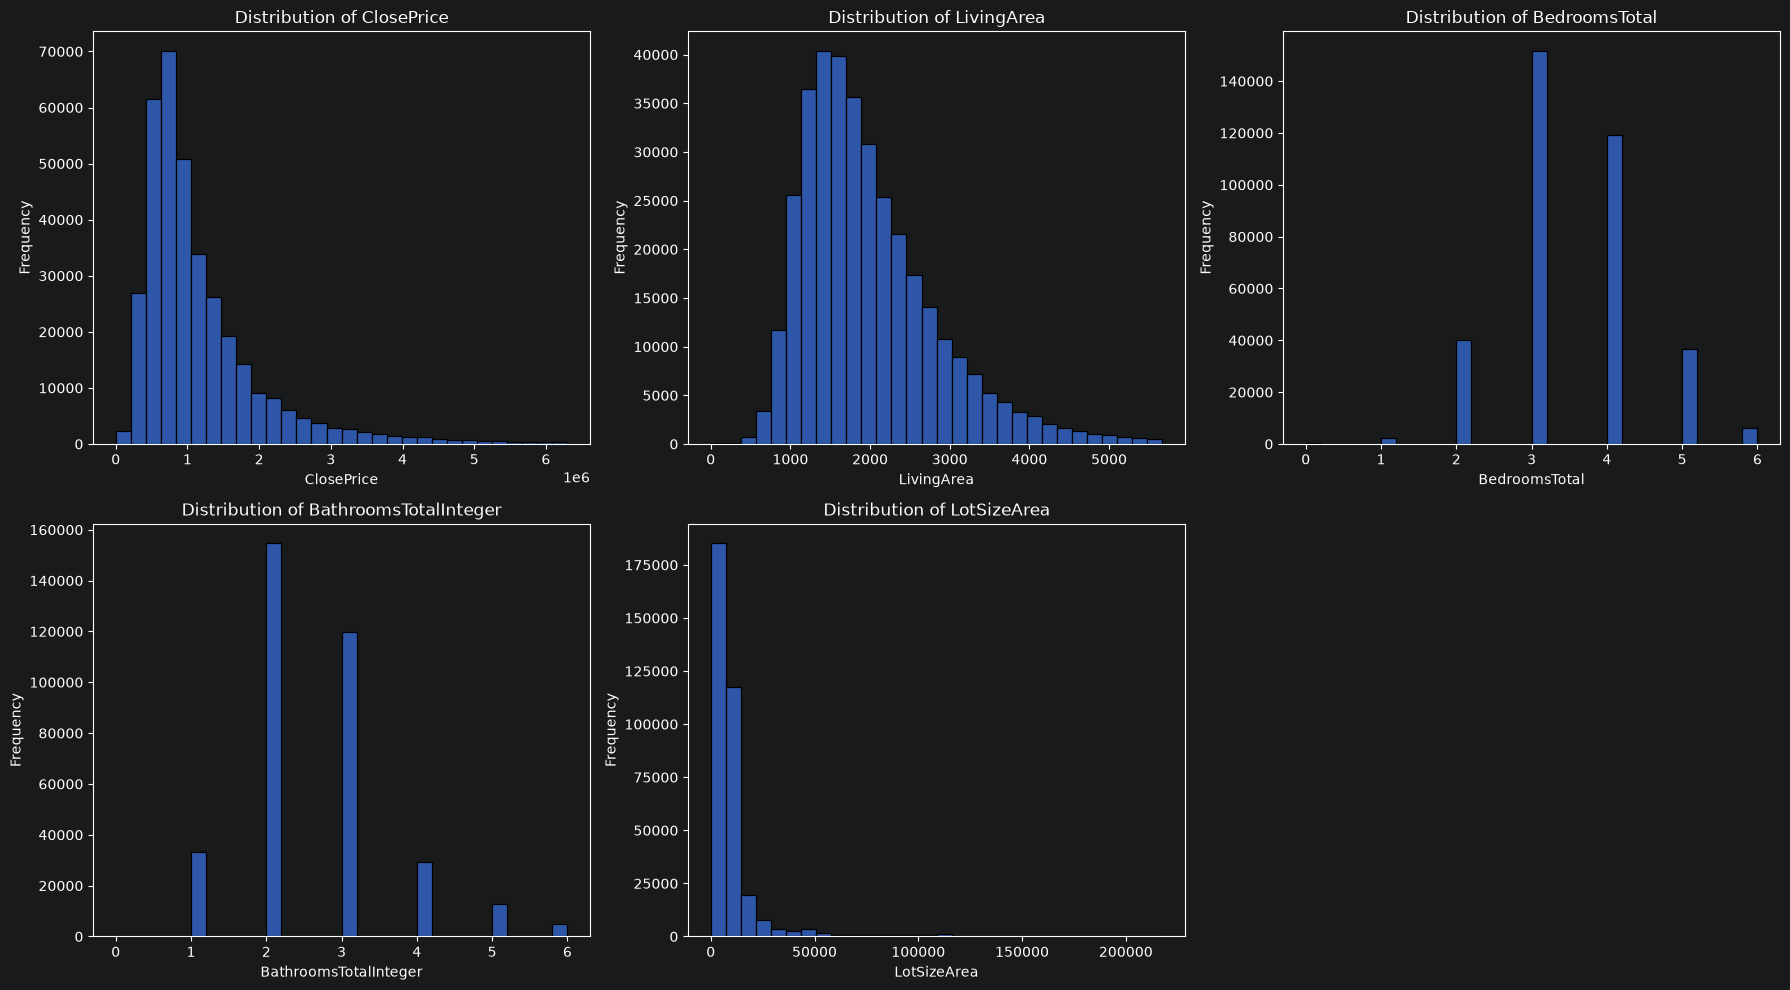

In [123]:
plt.figure(figsize=(18, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    data = restricted_df[col].dropna()
    data = data[data <= data.quantile(0.99)]
    sns.histplot(data, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

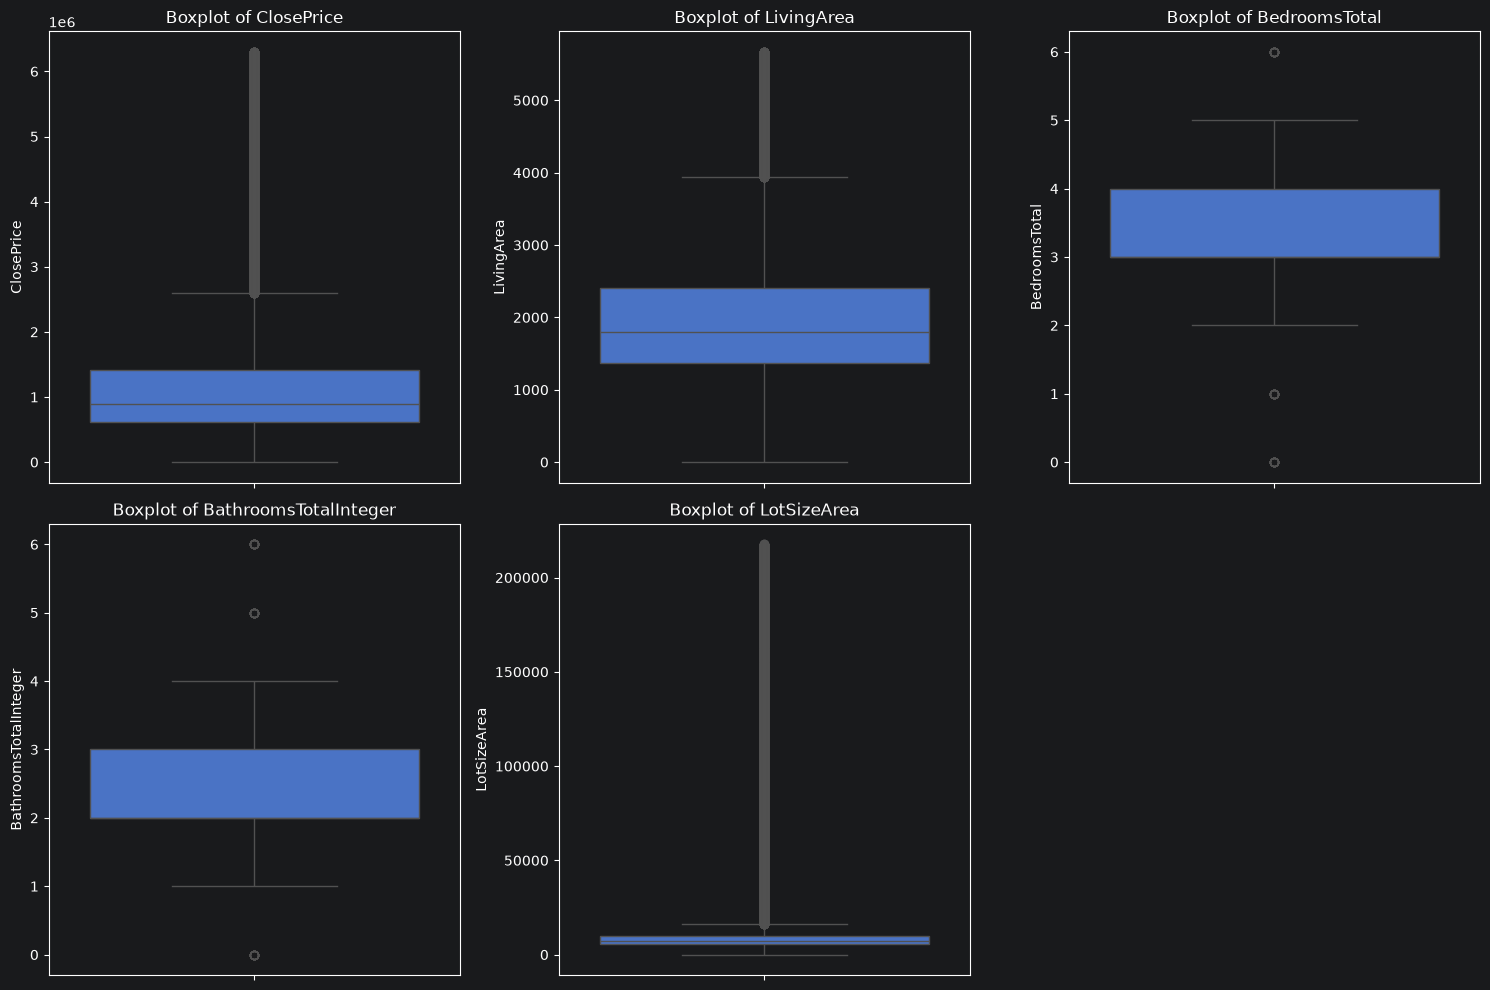

In [124]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    data = restricted_df[col].dropna()
    data = data[data <= data.quantile(0.99)]
    sns.boxplot(y=data)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Plotting 341,268 rows


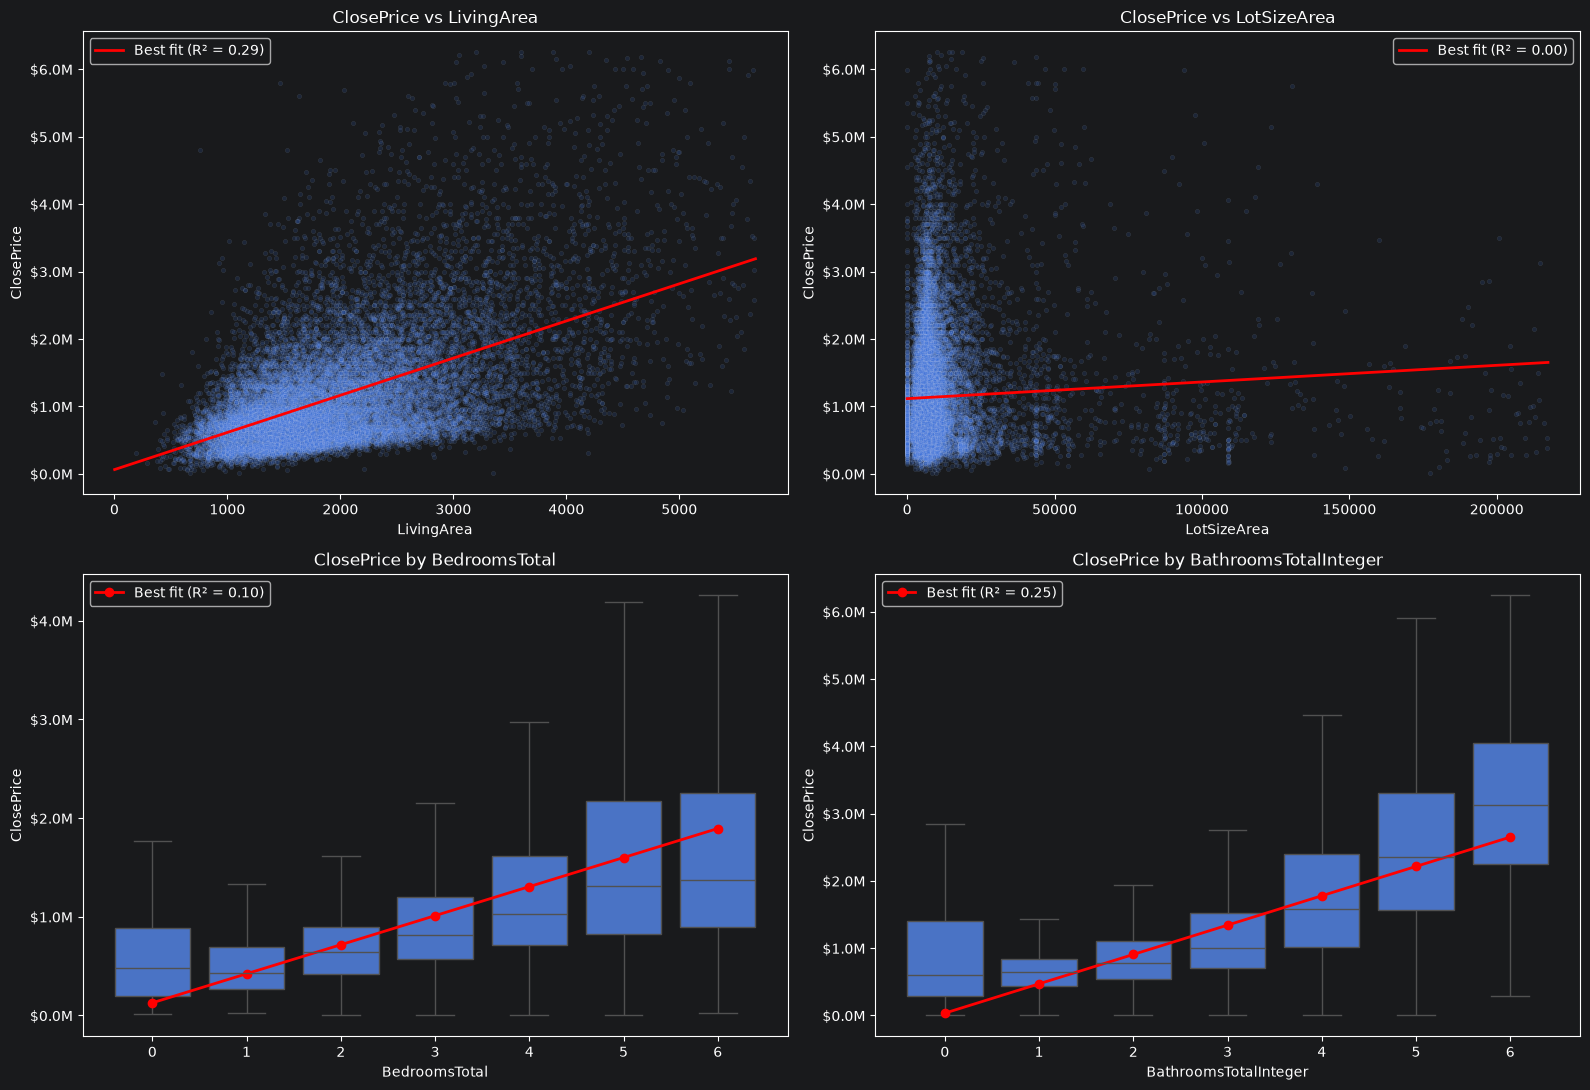

In [125]:
target = 'ClosePrice'
continuous = ['LivingArea', 'LotSizeArea']
discrete = ['BedroomsTotal', 'BathroomsTotalInteger']

# Plotting copy
plot_df = restricted_df[[target] + continuous + discrete].dropna()
plot_df = plot_df[(plot_df[target] > 0) & (plot_df['LivingArea'] > 0) & (plot_df['LotSizeArea'] > 0)]

# Trim the top 1% of each column so the plots are readable
mask = pd.Series(True, index=plot_df.index)
for c in [target] + continuous + discrete:
    mask &= plot_df[c] <= plot_df[c].quantile(0.99)
plot_df = plot_df[mask]
print(f'Plotting {len(plot_df):,} rows')

# Sample only for drawing the points
# The fit uses all plotted rows
scatter_df = plot_df.sample(min(20_000, len(plot_df)), random_state=42)

def fit_line(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    return slope, intercept, r2

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
money = mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')

# Scatter plots + best-fit line
for ax, col in zip(axes[0], continuous):
    sns.scatterplot(data=scatter_df, x=col, y=target, alpha=0.15, s=10, ax=ax)
    slope, intercept, r2 = fit_line(plot_df[col], plot_df[target])
    xs = np.linspace(plot_df[col].min(), plot_df[col].max(), 100)
    ax.plot(xs, slope * xs + intercept, color='red', lw=2,
            label=f'Best fit (R² = {r2:.2f})')
    ax.set_title(f'{target} vs {col}')
    ax.yaxis.set_major_formatter(money)
    ax.legend()

# Box plots + best-fit line through the category positions
for ax, col in zip(axes[1], discrete):
    d = plot_df.assign(**{col: plot_df[col].astype(int)})
    cats = sorted(d[col].unique())
    sns.boxplot(data=d, x=col, y=target, order=cats, showfliers=False, ax=ax)
    slope, intercept, r2 = fit_line(d[col], d[target])
    ax.plot(range(len(cats)), [slope * c + intercept for c in cats],
            color='red', marker='o', lw=2, label=f'Best fit (R² = {r2:.2f})')
    ax.set_title(f'{target} by {col}')
    ax.yaxis.set_major_formatter(money)
    ax.legend()

plt.tight_layout()
plt.show()